# Laboratori 1 — Insertion Sort & Selection Sort

## 1. Teoria

### Çfarë është Sorting (Renditja)?

Sorting është procesi i rregullimit të elementeve në një listë sipas një rendi të caktuar (zakonisht rritës ose zbritës). Është një nga problemet më themelore në shkencën kompjuterike.

### Pse është i rëndësishëm Sorting?

- Lehtëson kërkimin e të dhënave
- Përdoret si hap paraprak për algoritme të tjera
- Na mëson teknika të rëndësishme algoritmike

---

## Algoritmet që do të studiojmë sot

### 1. Insertion Sort

**Ideja:** Fut çdo element në pozicionin e duhur në pjesën e renditur të listës.

**Si funksionon:** Sikur të renditësh letra në dorë — merr një letër dhe e vendos në vendin e duhur mes letrave që ke renditur më parë.

**Veçori:** Performanca varet nga rendi fillestar i të dhënave!

### 2. Selection Sort

**Ideja:** Në çdo hap, gjej elementin më të vogël dhe vendose në pozicionin e duhur.

**Si funksionon:** Gjej numrin më të vogël në listë, vendose në fillim. Përsërit për pjesën tjetër.

**Veçori:** Performanca është e njëjtë pavarësisht nga rendi fillestar!

In [2]:
import pygame
import random
import os

pygame.init()

screen = pygame.display.set_mode((1280, 780), pygame.RESIZABLE)
pygame.display.set_caption("Insertion Sort")

font_medium = pygame.font.Font(None, 30)
font_small  = pygame.font.Font(None, 22)

BG         = (18, 18, 30)
BAR_UNSORT = (60, 60, 90)
BAR_SORTED = (72, 199, 142)
BAR_KEY    = (255, 99, 99)
BAR_INSERT = (255, 220, 50)
TEXT_COL   = (220, 220, 240)
ACCENT     = (100, 100, 160)
PANEL_COL  = (28, 28, 45)

raw = input("Shkruaj numrat (ose Enter për listë rastësore): ").strip()
try:    lst = [int(x) for x in raw.split()] if raw else random.sample(range(1, 51), 20)
except: lst = random.sample(range(1, 51), 20)
original = lst.copy()

i, phase = 1, "fillo"
key, insert_pos, shift_count = None, None, 0
comparisons, shifts = 0, 0
red, green, yellow = -1, -1, -1
msg = "Shtyp SPACE për të filluar"

def draw():
    W, H = screen.get_size()
    screen.fill(BG)
    n  = len(lst)
    P  = 50
    CT = 80
    CB = H - 150
    CW = W - 2 * P
    CH = CB - CT
    bw = min(120, CW // n)
    gap = max(4, bw // 6)
    sx = P + (CW - n * bw) // 2
    lo, hi = min(lst), max(lst)
    scale = (CH - 40) / (hi - lo) if hi > lo else CH - 40

    pygame.draw.rect(screen, PANEL_COL, (P-15, CT-15, CW+30, CH+30), border_radius=12)

    for idx, val in enumerate(lst):
        x  = sx + idx * bw + gap // 2
        bh = int((val - lo) * scale) + 30
        y  = CB - bh
        w  = bw - gap
        color = BAR_KEY if idx==red else BAR_INSERT if idx==yellow else BAR_SORTED if idx<=green else BAR_UNSORT
        pygame.draw.rect(screen, (10,10,20), (x+3, y+3, w, bh), border_radius=6)
        pygame.draw.rect(screen, color,      (x,   y,   w, bh), border_radius=6)
        pygame.draw.rect(screen, tuple(min(255, c+60) for c in color), (x+4, y+2, w-8, 4), border_radius=3)
        t = font_small.render(str(val), True, TEXT_COL)
        screen.blit(t, (x + w//2 - t.get_width()//2, y - 18))

    lx = P
    for label, col in [("Sorted", BAR_SORTED), ("Current Key", BAR_KEY), ("Just Inserted", BAR_INSERT), ("Unsorted", BAR_UNSORT)]:
        pygame.draw.rect(screen, col, (lx, 22, 24, 24), border_radius=5)
        t = font_small.render(label, True, TEXT_COL)
        screen.blit(t, (lx + 32, 26))
        lx += t.get_width() + 60

    pygame.draw.rect(screen, PANEL_COL, (P-15, CB+15, CW+30, 120), border_radius=12)
    screen.blit(font_small.render("Lista:  [" + ", ".join(map(str, lst)) + "]", True, TEXT_COL), (P, CB+28))
    if green >= 0:
        screen.blit(font_small.render(f"Pjesa e renditur: indekset 0 - {green}", True, BAR_SORTED), (P, CB+50))
    screen.blit(font_medium.render(msg, True, TEXT_COL), (P, CB+72))
    screen.blit(font_small.render(f"Krahasime: {comparisons}   |   Zhvendosje: {shifts}   |   SPACE: hapi tjetër   |   R: rivendos", True, ACCENT), (P, H-25))
    pygame.display.flip()

def step():
    global i, phase, key, insert_pos, shift_count, comparisons, shifts, red, green, yellow, msg
    if phase == "fillo":
        phase, msg = "show_key", "Duke filluar Insertion Sort...  Shtyp SPACE"
    elif phase == "show_key":
        if i >= len(lst):
            phase, red, yellow, green = "done", -1, -1, len(lst)-1
            msg = f"✓  E RENDITUR!   {comparisons} krahasime,  {shifts} zhvendosje  —  Shtyp R për rivendosje"
            return
        key = lst[i]; red, green = i, i-1
        k, shift_count = i-1, 0
        while k >= 0 and lst[k] > key: comparisons += 1; shift_count += 1; k -= 1
        if k >= 0: comparisons += 1
        insert_pos = k + 1
        msg = (f"KEY = {key}  (indeksi {i})  -  do të zhvendosë {shift_count} elemente djathtas" if shift_count > 0
               else f"KEY = {key}  (indeksi {i})  -  tashmë në pozicionin e duhur")
        phase = "insert"
    elif phase == "insert":
        if shift_count > 0:
            for j in range(i, insert_pos, -1): lst[j] = lst[j-1]
            lst[insert_pos] = key; shifts += shift_count; yellow = insert_pos
            msg = f"Inserted KEY = {key}  në indeksin {insert_pos}  (zhvendosur {shift_count} elemente djathtas)"
        else:
            yellow = i; msg = f"KEY = {key}  mbeti në indeksin {i}  (tashmë e renditur)"
        red = -1; green = i; i += 1; phase = "show_key"
    elif phase == "done":
        msg = "Tashmë e renditur!  Shtyp R për rivendosje"

def reset():
    global lst, i, phase, key, insert_pos, shift_count, comparisons, shifts, red, green, yellow, msg
    lst = original.copy(); i, phase = 1, "fillo"
    key = insert_pos = None; comparisons = shifts = shift_count = 0
    red = green = yellow = -1; msg = "Shtyp SPACE për të filluar"

draw()
clock = pygame.time.Clock()
running = True
while running:
    clock.tick(60)
    for e in pygame.event.get():
        if e.type == pygame.QUIT:
            pygame.quit()
            os._exit(0)
        elif e.type == pygame.VIDEORESIZE: draw()
        elif e.type == pygame.KEYDOWN:
            if   e.key == pygame.K_SPACE: step(); draw()
            elif e.key == pygame.K_r:     reset(); draw()

pygame 2.6.1 (SDL 2.28.4, Python 3.9.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


: 

In [ ]:
# Ushtrim 2: Insertion Sort per nje liste e renditur ne renditje random
import time
import random
import plotly.graph_objects as go

def insertion_sort(lst):
    for i in range(1, len(lst)):
        v, j = lst[i], i - 1
        while j >= 0 and lst[j] > v:
            lst[j + 1] = lst[j]
            j -= 1
        lst[j + 1] = v

def mat_kohen(lst):
    c = lst.copy()
    t = time.perf_counter()
    insertion_sort(c)
    return time.perf_counter() - t

def crregullo(lst, nivel):
    lst = lst.copy()
    for _ in range(int(nivel * len(lst) * 3)):
        i, j = random.sample(range(len(lst)), 2)
        lst[i], lst[j] = lst[j], lst[i]
    return lst

raw = input("Shkruaj numrat e ndarë me hapësirë: ").strip()
try:
    base = sorted(int(x) for x in raw.split())
except:
    base = list(range(1, 21))

STEPS     = 60
nivelet   = [i / (STEPS - 1) for i in range(STEPS)]
renditjet = [crregullo(base, niv) for niv in nivelet]
kohet     = [mat_kohen(r) for r in renditjet]

fig, ax = go.subplots(figsize=(13, 6))
go.subplots_adjust(bottom=0.15)

ax.scatter(range(STEPS), kohet, c=kohet, cmap='RdYlGn_r', s=55, zorder=4, picker=5)
ax.plot(range(STEPS), kohet, color='#aaaaaa', lw=1.2, zorder=3, alpha=0.6)
ax.axvspan(0, STEPS * 0.35, alpha=0.08, color='#2ecc71')
ax.axvspan(STEPS * 0.35, STEPS, alpha=0.08, color='#e74c3c')

ymax = max(kohet)
dy   = ymax - min(kohet)
ax.text(STEPS * 0.17, ymax + dy * 0.02, 'Pothuajse e renditur', ha='center', fontsize=9, color='#27ae60', fontweight='bold')
ax.text(STEPS * 0.67, ymax + dy * 0.02, 'Shumë e çrregullt',    ha='center', fontsize=9, color='#c0392b', fontweight='bold')

tick_idx = [int(i * (STEPS - 1) / 5) for i in range(6)]
ax.set_xticks(tick_idx)
ax.set_xticklabels([f'Renditja {i + 1}' for i in tick_idx], fontsize=9)
ax.set_xlabel('Renditja e listës  (nga pothuajse e renditur  →  shumë e çrregullt)')
ax.set_ylabel('Koha (sekonda)')
ax.set_title(f'Insertion Sort — E njëjta listë ({len(base)} elementë) me renditje të ndryshme')
ax.set_xlim(-1, STEPS)
ax.grid(True, alpha=0.25)

annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                    bbox=dict(boxstyle="round,pad=0.5", fc="#1e1e2e", ec="#4a90d9", lw=1.5, alpha=0.95),
                    arrowprops=dict(arrowstyle="->", color="#4a90d9"),
                    fontsize=9, color="white", zorder=10)
annot.set_visible(False)
highlight, = ax.plot([], [], 'o', ms=14, color='white', zorder=5, alpha=0.5)

def on_hover(event):
    if event.inaxes != ax:
        annot.set_visible(False)
        highlight.set_data([], [])
        fig.canvas.draw_idle()
        return
    idx = int(np.argmin([abs(event.xdata - i) for i in range(STEPS)]))
    if abs(event.xdata - idx) > 2:
        annot.set_visible(False)
        highlight.set_data([], [])
        fig.canvas.draw_idle()
        return
    annot.xy = (idx, kohet[idx])
    annot.set_text(f"Renditja {idx + 1}  |  Çrregullsi: {int(nivelet[idx] * 100)}%\n"
                   f"Koha: {kohet[idx] * 1000:.4f} ms\nLista: {renditjet[idx]}")
    annot.xyann = (15 if idx < STEPS * 0.75 else -180, 15)
    annot.set_visible(True)
    highlight.set_data([idx], [kohet[idx]])
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("motion_notify_event", on_hover)
fig.show()

NameError: name 'plt' is not defined

In [ ]:
# Ushtrim 3: Si funksionon Selection Sort

import pygame
import random

pygame.init()

screen = pygame.display.set_mode((1280, 780), pygame.RESIZABLE)
pygame.display.set_caption("Selection Sort")

font_medium = pygame.font.Font(None, 30)
font_small  = pygame.font.Font(None, 22)

BG         = (18, 18, 30)
BAR_UNSORT = (60, 60, 90)
BAR_SORTED = (72, 199, 142)
BAR_SCAN   = (255, 99, 99)
BAR_MIN    = (255, 220, 50)
BAR_I      = (180, 100, 255)
TEXT_COL   = (220, 220, 240)
ACCENT     = (100, 100, 160)
PANEL_COL  = (28, 28, 45)

raw = input("Shkruaj numrat (ose Enter për listë rastësore): ").strip()
try:    lst = [int(x) for x in raw.split()] if raw else random.sample(range(1, 51), 20)
except: lst = random.sample(range(1, 51), 20)
original = lst.copy()

i, phase = 0, "fillo"
min_idx, scan_idx = 0, 0
comparisons, swaps = 0, 0
green = -1
msg = "Shtyp SPACE për të filluar"

def draw():
    W, H = screen.get_size()
    screen.fill(BG)
    n   = len(lst)
    P   = 50
    CT  = 80
    CB  = H - 150
    CW  = W - 2 * P
    CH  = CB - CT
    bw  = min(120, CW // n)
    gap = max(4, bw // 6)
    sx  = P + (CW - n * bw) // 2
    lo, hi = min(lst), max(lst)
    scale  = (CH - 40) / (hi - lo) if hi > lo else CH - 40

    pygame.draw.rect(screen, PANEL_COL, (P-15, CT-15, CW+30, CH+30), border_radius=12)

    for idx, val in enumerate(lst):
        x  = sx + idx * bw + gap // 2
        bh = int((val - lo) * scale) + 30
        y  = CB - bh
        w  = bw - gap
        if idx <= green:
            color = BAR_SORTED
        elif idx == min_idx and phase in ("scan", "swap"):
            color = BAR_MIN
        elif idx == scan_idx and phase == "scan":
            color = BAR_SCAN
        elif idx == i and phase in ("show_i", "scan", "swap"):
            color = BAR_I
        else:
            color = BAR_UNSORT
        pygame.draw.rect(screen, (10,10,20), (x+3, y+3, w, bh), border_radius=6)
        pygame.draw.rect(screen, color,      (x,   y,   w, bh), border_radius=6)
        pygame.draw.rect(screen, tuple(min(255, c+60) for c in color), (x+4, y+2, w-8, 4), border_radius=3)
        t = font_small.render(str(val), True, TEXT_COL)
        screen.blit(t, (x + w//2 - t.get_width()//2, y - 18))

    lx = P
    for label, col in [("Sorted", BAR_SORTED), ("Pozicioni i", BAR_I), ("Minimumi", BAR_MIN), ("Duke skanuar", BAR_SCAN), ("Pa renditur", BAR_UNSORT)]:
        pygame.draw.rect(screen, col, (lx, 22, 24, 24), border_radius=5)
        t = font_small.render(label, True, TEXT_COL)
        screen.blit(t, (lx + 32, 26))
        lx += t.get_width() + 60

    pygame.draw.rect(screen, PANEL_COL, (P-15, CB+15, CW+30, 120), border_radius=12)
    screen.blit(font_small.render("Lista:  [" + ", ".join(map(str, lst)) + "]", True, TEXT_COL), (P, CB+28))
    if green >= 0:
        screen.blit(font_small.render(f"Pjesa e renditur: indekset 0 - {green}", True, BAR_SORTED), (P, CB+50))
    screen.blit(font_medium.render(msg, True, TEXT_COL), (P, CB+72))
    screen.blit(font_small.render(f"Krahasime: {comparisons}   |   Shkëmbime: {swaps}   |   SPACE: hapi tjetër   |   R: rivendos", True, ACCENT), (P, H-25))
    pygame.display.flip()

def step():
    global i, phase, min_idx, scan_idx, comparisons, swaps, green, msg
    if phase == "fillo":
        phase   = "show_i"
        min_idx = i
        scan_idx = i
        msg     = "Duke filluar Selection Sort...  Shtyp SPACE"
    elif phase == "show_i":
        if i >= len(lst) - 1:
            phase = "done"
            green = len(lst) - 1
            msg   = f"✓  E RENDITUR!   {comparisons} krahasime,  {swaps} shkëmbime  —  Shtyp R për rivendosje"
            return
        min_idx  = i
        scan_idx = i + 1
        phase    = "scan"
        msg      = f"Pozicioni i={i},  duke kërkuar minimumin në intervalin [{i}, {len(lst)-1}]"
    elif phase == "scan":
        comparisons += 1
        if lst[scan_idx] < lst[min_idx]:
            min_idx = scan_idx
            msg = f"Minimum i ri gjetur: {lst[min_idx]}  (indeksi {min_idx})"
        else:
            msg = f"Duke krahasuar {lst[scan_idx]} me minimumin aktual {lst[min_idx]}..."
        scan_idx += 1
        if scan_idx >= len(lst):
            phase = "swap"
            msg   = f"Minimumi është {lst[min_idx]}  (indeksi {min_idx})  —  do të shkëmbehet me indeksin {i}"
    elif phase == "swap":
        if min_idx != i:
            lst[i], lst[min_idx] = lst[min_idx], lst[i]
            swaps += 1
            msg = f"Shkëmbim: {lst[min_idx]} ↔ {lst[i]}  —  {lst[i]} tani është në pozicionin {i}"
        else:
            msg = f"{lst[i]} ishte tashmë në pozicionin e duhur {i}"
        green    = i
        i       += 1
        min_idx  = i
        scan_idx = i
        phase    = "show_i"
    elif phase == "done":
        msg = "Tashmë e renditur!  Shtyp R për rivendosje"

def reset():
    global lst, i, phase, min_idx, scan_idx, comparisons, swaps, green, msg
    lst      = original.copy()
    i, phase = 0, "fillo"
    min_idx  = scan_idx = 0
    comparisons = swaps = 0
    green    = -1
    msg      = "Shtyp SPACE për të filluar"

import os

draw()
clock   = pygame.time.Clock()
running = True
while running:
    clock.tick(60)
    for e in pygame.event.get():
        if e.type == pygame.QUIT:
            pygame.quit()
            os._exit(0)
        elif e.type == pygame.VIDEORESIZE: draw()
        elif e.type == pygame.KEYDOWN:
            if   e.key == pygame.K_SPACE: step(); draw()
            elif e.key == pygame.K_r:     reset(); draw()

pygame 2.6.1 (SDL 2.28.4, Python 3.9.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


: 


USHTRIM 1: LISTA E VOGËL (10)

INSERTION SORT:
Random:  0.00000333 sek
Sorted:  0.00000092 sek (RASTI MË I MIRË)
Reverse: 0.00000271 sek (RASTI MË I KEQ)

SELECTION SORT:
Random:  0.00000271 sek
Sorted:  0.00000212 sek
Reverse: 0.00000204 sek


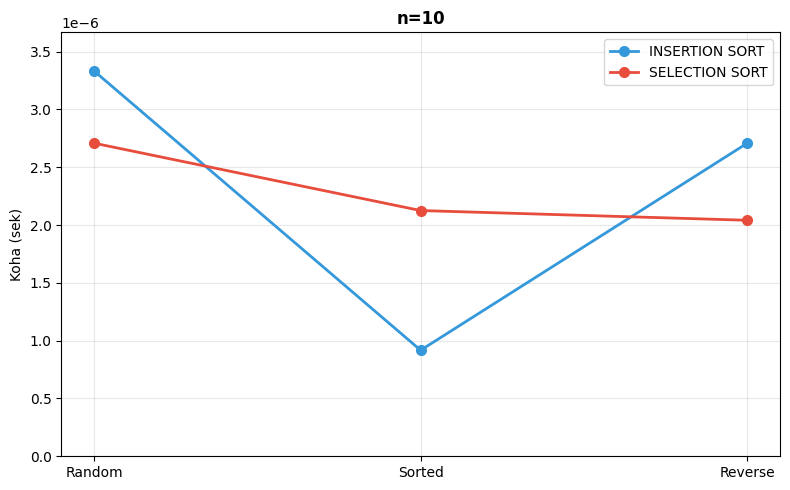


USHTRIM 2: LISTA MESATARE (100)

INSERTION SORT:
Random:  0.00012608 sek
Sorted:  0.00000525 sek (RASTI MË I MIRË)
Reverse: 0.00022729 sek (RASTI MË I KEQ)

SELECTION SORT:
Random:  0.00012596 sek
Sorted:  0.00011354 sek
Reverse: 0.00011612 sek


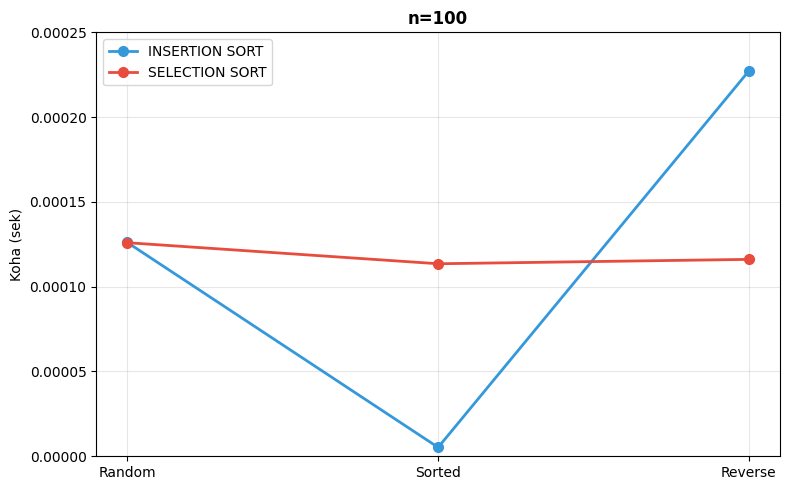


USHTRIM 3: LISTA E MADHE (1000)

INSERTION SORT:
Random:  0.01125421 sek
Sorted:  0.00005304 sek (RASTI MË I MIRË)
Reverse: 0.02352396 sek (RASTI MË I KEQ)

SELECTION SORT:
Random:  0.01173654 sek
Sorted:  0.01231571 sek
Reverse: 0.01278479 sek


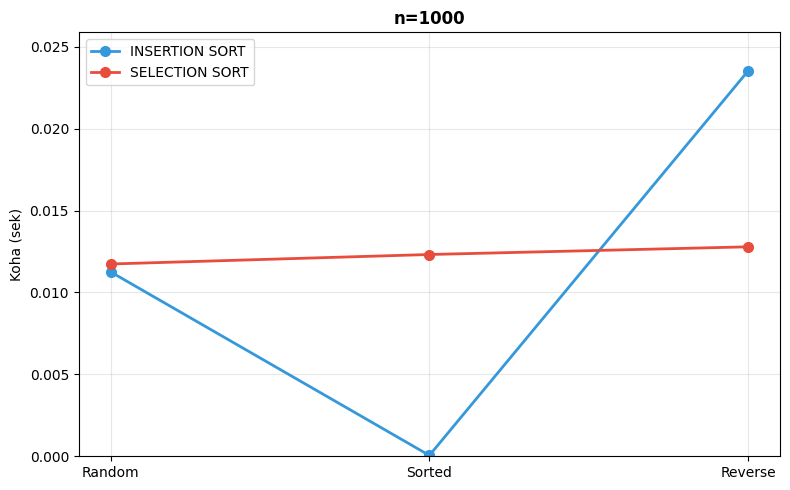


USHTRIM 4: LISTA SHUMË E MADHE (10000)

INSERTION SORT:
Random:  1.30617596 sek
Sorted:  0.00058304 sek (RASTI MË I MIRË)
Reverse: 2.56276900 sek (RASTI MË I KEQ)

SELECTION SORT:
Random:  1.22290271 sek
Sorted:  1.26330888 sek
Reverse: 1.25283613 sek


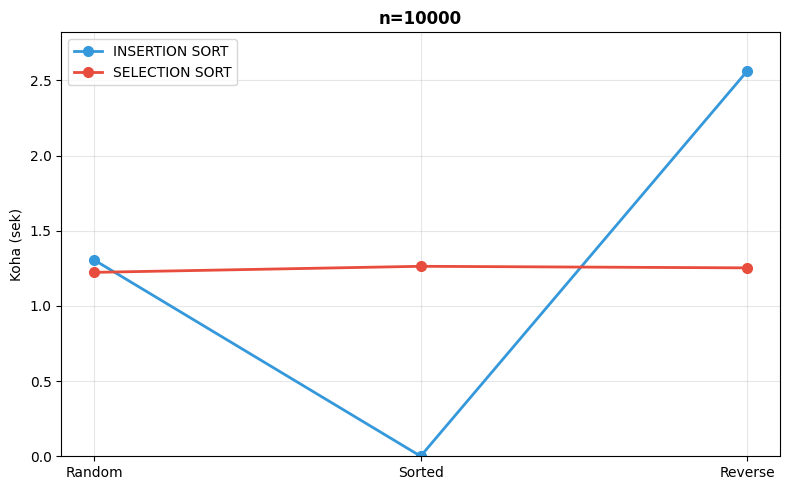



PËRFUNDIME KRYESORE

1. INSERTION SORT:
   - Ka rast më të mirë: lista e renditur (shumë e shpejtë)
   - Ka rast më të keq: lista kundërt (më e ngadaltë)
   - Performancë e ndryshme sipas radhës fillestare të të dhënave

2. SELECTION SORT:
   - Ka të njëjtën kohë për të gjitha rastet!
   - Gjithmonë bën O(n²) krahasime, pavarësisht nga input-i

3. KRAHASIMI INSERTION vs SELECTION:
   - Për lista të renditura: Insertion Sort >>> Selection Sort
   - Për lista random: Insertion Sort ≈ Selection Sort
   - Për lista kundërt: Selection Sort > Insertion Sort


In [ ]:
# Ushtrim 4: Insertion Sort vs Selection Sort

import time
import random
import matplotlib.pyplot as plt

def insertion_sort(lista):
    n = len(lista)
    for i in range(1, n):
        vlera = lista[i]
        j = i - 1
        while j >= 0 and lista[j] > vlera:
            lista[j + 1] = lista[j]
            j -= 1
        lista[j + 1] = vlera
    return lista

def selection_sort(lista):
    n = len(lista)
    for i in range(n - 1):
        min_idx = i
        for j in range(i + 1, n):
            if lista[j] < lista[min_idx]:
                min_idx = j
        lista[i], lista[min_idx] = lista[min_idx], lista[i]
    return lista

def mat_kohen(funksioni, lista):
    lista_kopjuar = lista.copy()
    t = time.perf_counter()
    funksioni(lista_kopjuar)
    return time.perf_counter() - t

def krijo_grafik(n, ins_koha, em1, sel_koha, em2):
    fig, ax = plt.subplots(figsize=(8, 5))
    raste = ['Random', 'Sorted', 'Reverse']
    lines = []
    lines += ax.plot(raste, ins_koha, marker='o', color='#3498db', linewidth=2, markersize=7, label=em1)
    lines += ax.plot(raste, sel_koha, marker='o', color='#e74c3c', linewidth=2, markersize=7, label=em2)
    ax.set_ylabel('Koha (sek)')
    ax.set_title(f'n={n}', fontweight='bold')
    ax.set_ylim(0, max(max(ins_koha), max(sel_koha)) * 1.1)
    ax.legend()
    ax.grid(alpha=0.3)

    annot = ax.annotate("", xy=(0, 0), xytext=(10, 10), textcoords="offset points",
                        bbox=dict(boxstyle="round,pad=0.4", fc="#1e1e2e", ec="#aaaaaa", lw=1, alpha=0.9),
                        fontsize=9, color="white")
    annot.set_visible(False)

    te_gjitha = [(raste, ins_koha, em1), (raste, sel_koha, em2)]

    def on_hover(event):
        if event.inaxes != ax:
            annot.set_visible(False)
            fig.canvas.draw_idle()
            return
        for line, (r, koha, em) in zip(lines, te_gjitha):
            xdata = line.get_xdata()
            ydata = line.get_ydata()
            for xi, yi in zip(range(len(xdata)), ydata):
                x_px, y_px = ax.transData.transform((xi, yi))
                if abs(event.x - x_px) < 10 and abs(event.y - y_px) < 10:
                    annot.xy = (xi, yi)
                    annot.set_text(f"{em}\n{r[xi]}: {yi:.8f} sek")
                    annot.set_visible(True)
                    fig.canvas.draw_idle()
                    return
        annot.set_visible(False)
        fig.canvas.draw_idle()

    fig.canvas.mpl_connect("motion_notify_event", on_hover)
    plt.tight_layout()
    plt.show()

def krahasim_algoritmesh(alg1, em1, alg2, em2):
    madhesite = [10, 100, 1000, 10000]
    emertimet = ["LISTA E VOGËL (10)", "LISTA MESATARE (100)", "LISTA E MADHE (1000)", "LISTA SHUMË E MADHE (10000)"]

    for i, n in enumerate(madhesite):
        print("\n" + "=" * 70)
        print(f"USHTRIM {i + 1}: {emertimet[i]}")
        print("=" * 70)

        lista_random   = [7, 3, 9, 2, 5, 8, 1, 6, 4, 10] if n == 10 else random.sample(range(1, n + 1), n)
        lista_sorted   = list(range(1, n + 1))
        lista_reverse  = list(range(n, 0, -1))

        print(f"\n{em1}:")
        k1r = mat_kohen(alg1, lista_random)
        k1s = mat_kohen(alg1, lista_sorted)
        k1v = mat_kohen(alg1, lista_reverse)
        print(f"Random:  {k1r:.8f} sek")
        print(f"Sorted:  {k1s:.8f} sek (RASTI MË I MIRË)")
        print(f"Reverse: {k1v:.8f} sek (RASTI MË I KEQ)")

        print(f"\n{em2}:")
        k2r = mat_kohen(alg2, lista_random)
        k2s = mat_kohen(alg2, lista_sorted)
        k2v = mat_kohen(alg2, lista_reverse)
        print(f"Random:  {k2r:.8f} sek")
        print(f"Sorted:  {k2s:.8f} sek")
        print(f"Reverse: {k2v:.8f} sek")

        krijo_grafik(n, [k1r, k1s, k1v], em1, [k2r, k2s, k2v], em2)

krahasim_algoritmesh(insertion_sort, "INSERTION SORT", selection_sort, "SELECTION SORT")

print("\n\n" + "=" * 70)
print("PËRFUNDIME KRYESORE")
print("=" * 70)
print("\n1. INSERTION SORT:")
print("   - Ka rast më të mirë: lista e renditur (shumë e shpejtë)")
print("   - Ka rast më të keq: lista kundërt (më e ngadaltë)")
print("   - Performancë e ndryshme sipas radhës fillestare të të dhënave")
print("\n2. SELECTION SORT:")
print("   - Ka të njëjtën kohë për të gjitha rastet!")
print("   - Gjithmonë bën O(n²) krahasime, pavarësisht nga input-i")
print("\n3. KRAHASIMI INSERTION vs SELECTION:")
print("   - Për lista të renditura: Insertion Sort >>> Selection Sort")
print("   - Për lista random: Insertion Sort ≈ Selection Sort")
print("   - Për lista kundërt: Selection Sort > Insertion Sort")